# Homework 1 — Number of epochs

How many epochs should the final mlp_4out_emb train for? Model comparison ([mlp.ipynb](mlp.ipynb)) and
[regularization_test.ipynb](regularization_test.ipynb) train for 10, and validation still improves at epoch 10.

Here: 20 epochs on all 4 seasonal folds ([adversarial.ipynb](../validation/adversarial.ipynb), step 2).
**Rule:** use the epoch with the lowest validation RMSLE averaged over the folds.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # the ashrae package lives in the homework folder
from ashrae.config import FOLDS
from ashrae.data import read_processed, split
from ashrae.features import build_features
from ashrae.modeling import MeterMLP, make_loaders
from ashrae.plots import plot_curves
from ashrae.tracking import Experiment

EPOCHS = 20
N_TRAIN, N_VAL = 2_000_000, 500_000  # rows sampled per fold, as in regularization_test.ipynb
experiment = Experiment("ashrae-epochs")

2026/09/27 13:36:59 INFO mlflow.tracking.fluent: Experiment with name 'ashrae-epochs' does not exist. Creating a new experiment.


MLflow: sqlite:////Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/Homeworks/Homework 1/mlflow.db, experiment 'ashrae-epochs', session 2026-09-27 13:36:58


## Data

Same folds, rows and features as [regularization_test.ipynb](regularization_test.ipynb).

In [2]:
df = read_processed()
n_buildings = int(df.building_id.max()) + 1


def fold_loaders(val_months):
    train_df, val_df = split(df, val_months, N_TRAIN, N_VAL)
    year_median = train_df.year_built.median()
    return make_loaders(train_df, val_df, build_features(train_df, year_median), build_features(val_df, year_median))


loaders = {name: fold_loaders(months) for name, months in FOLDS.items()}
n_features = loaders["Jan–Mar"][0].dataset.x.shape[1]
del df

## Training

mlp_4out_emb, Adam, 20 epochs per fold. Validation RMSLE is logged after every epoch, on all rows (as Kaggle scores).

In [3]:
curves = {}
for fold, (train_loader, val_loader, _) in loaders.items():
    _, run_id = experiment.fit(lambda: MeterMLP(n_features, n_buildings), train_loader, val_loader,
                               run_name=f"mlp_4out_emb | {fold}", epochs=EPOCHS, tags={"fold": fold})
    curves[fold] = experiment.history(run_id, "val_rmsle")
    print(f"{fold}: best {min(curves[fold]):.3f} at epoch {int(np.argmin(curves[fold])) + 1}, "
          f"epoch 10 {curves[fold][9]:.3f}, epoch 20 {curves[fold][-1]:.3f}")

Jan–Mar: best 1.409 at epoch 17, epoch 10 1.421, epoch 20 1.415


Apr–Jun: best 1.210 at epoch 20, epoch 10 1.223, epoch 20 1.210


Jul–Sep: best 1.025 at epoch 19, epoch 10 1.048, epoch 20 1.026


Oct–Dec: best 1.093 at epoch 20, epoch 10 1.110, epoch 20 1.093


## Results

,Jan–Mar,Apr–Jun,Jul–Sep,Oct–Dec,average
epoch,,,,,
5,1.445,1.239,1.078,1.114,1.219
10,1.421,1.223,1.048,1.110,1.200
15,1.421,1.214,1.032,1.106,1.193
20,1.415,1.210,1.026,1.093,1.186


best epoch, fold average: 20


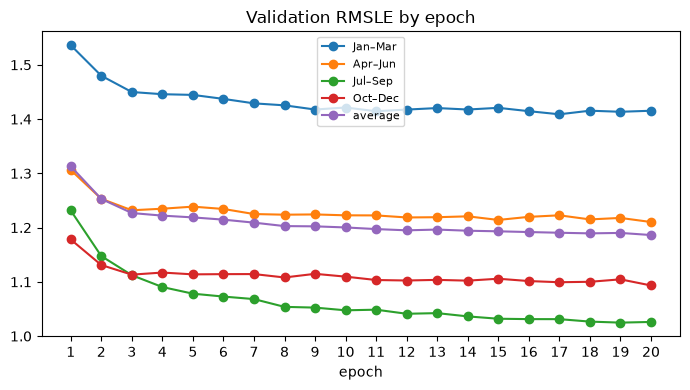

In [4]:
curves = pd.DataFrame(curves, index=pd.RangeIndex(1, EPOCHS + 1, name="epoch"))
curves["average"] = curves.mean(axis=1)
best_epoch = int(curves.average.idxmin())
display(curves.loc[[5, 10, 15, 20, best_epoch]].drop_duplicates().round(3))
print(f"best epoch, fold average: {best_epoch}")

fig, ax = plt.subplots(figsize=(7, 4))
plot_curves(ax, {col: curves[col].tolist() for col in curves}, "Validation RMSLE by epoch")
plt.tight_layout()

## Findings

- **Validation improves up to epoch 20, the last one tested.** Fold average: 1.219 (5 epochs) → 1.200 (10) → 1.193 (15)
  → 1.186 (20). Every fold is better at 20 than at 10, by 0.006–0.022.
- **The gains shrink:** 0.019 from 5 to 10 epochs, 0.014 from 10 to 20. More epochs may help a little more.
- **One fold is too noisy to read an epoch count from.** On Oct–Dec the score moves by ~0.01 between neighbouring epochs
  (1.115 at epoch 9, 1.103 at 11), so on that fold alone it seems to level off at ~9.
- **Decision:** the final model trains for 20 epochs ([mlp.ipynb](mlp.ipynb#test-predictions)). The 10 epochs used
  for model comparison in mlp.ipynb leave ~0.014 on the table for this model.

Scored on all rows (as Lightning logs it); one seed per fold.